In [1]:
# Hafta 4'te yazdığın MLP + BatchNorm kodunu sınıflara topla: Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential. Model tek bir Sequential olsun, eğitim döngüsü içindeki katmanların adını bilmesin. Loss eğrisi çizimini videodaki gibi düzelt.

## Görev 1

In [161]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [162]:
# read in all the words
words = open('turkce_isimler.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

103637
14
['Ada', 'Adaadem', 'Adaahmet', 'Adaali', 'Adaalp', 'Adaalparslan', 'Adaalper', 'Adaarda']


In [163]:
def lowercase(s):
    s = s.replace('İ', 'i').replace('I', 'ı')
    return s.lower()

words_cleaned = [lowercase(n) for n in words]
print(words_cleaned[:10])
words = words_cleaned.copy()

['ada', 'adaadem', 'adaahmet', 'adaali', 'adaalp', 'adaalparslan', 'adaalper', 'adaarda', 'adaasel', 'adaaslan']


In [164]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'y', 23: 'z', 24: 'ç', 25: 'ö', 26: 'ü', 27: 'ğ', 28: 'ı', 29: 'ş', 0: '.'}
30


In [165]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [166]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([891788, 8]) torch.Size([891788])
torch.Size([111351, 8]) torch.Size([111351])
torch.Size([111819, 8]) torch.Size([111819])


In [139]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> a
.......a --> y
......ay --> m
.....aym --> a
....ayma --> h
...aymah --> i
..aymahi --> r
.aymahir --> .
........ --> d
.......d --> o
......do --> ğ
.....doğ --> a
....doğa --> c
...doğac --> e
..doğace --> m
.doğacem --> .
........ --> f
.......f --> u
......fu --> r
.....fur --> k


In [167]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [168]:
torch.manual_seed(42); # seed rng for reproducibility

In [142]:
# original network
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22730


In [101]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.4144
  10000/ 200000: 1.4413
  20000/ 200000: 1.7853
  30000/ 200000: 1.4081
  40000/ 200000: 1.6868
  50000/ 200000: 1.6626
  60000/ 200000: 1.4601
  70000/ 200000: 1.5990
  80000/ 200000: 1.7615
  90000/ 200000: 1.5849
 100000/ 200000: 0.9423
 110000/ 200000: 1.4800
 120000/ 200000: 1.7072
 130000/ 200000: 1.5111
 140000/ 200000: 1.4984
 150000/ 200000: 1.4001
 160000/ 200000: 1.2572
 170000/ 200000: 1.2812
 180000/ 200000: 1.0631
 190000/ 200000: 1.3064


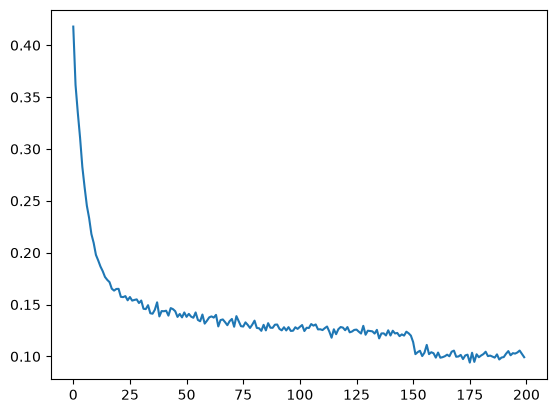

In [102]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [103]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [104]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.2263916730880737
val 1.2500290870666504


In [105]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

çınaryiğit.
onurjülide.
asumanbilek.
cemalra.
selimzameva.
ufukyağmur.
görkemdoğakan.
irfansibel.
metehangen.
sehernada.
oyaharuğ.
ibrahimsevgi.
ömerpelin.
uğurcaner.
yıldızderin.
ecedilay.
reşatoprak.
ihsancemay.
oğulcannazlı.
yazmetis.


In [ ]:
# 3 karakter ile training loss çıkıtsı :
'''
0/ 200000: 3.3959
  10000/ 200000: 2.1381
  20000/ 200000: 1.8054
  30000/ 200000: 1.4642
  40000/ 200000: 1.6180
  50000/ 200000: 1.3071
  60000/ 200000: 2.0340
  70000/ 200000: 1.3631
  80000/ 200000: 1.3020
  90000/ 200000: 1.1283
 100000/ 200000: 1.7322
 110000/ 200000: 1.3910
 120000/ 200000: 1.3836
 130000/ 200000: 1.4406
 140000/ 200000: 1.9076
 150000/ 200000: 1.7053
 160000/ 200000: 1.6166
 170000/ 200000: 1.4014
 180000/ 200000: 1.4839
 190000/ 200000: 1.2988
 
'''
# parametre sayısı:12730

# train 1.4505501985549927
# val 1.4633435010910034

## 3 karakter ile bir sonraki karakteri tahmin ettiğimizde loss eğrisi

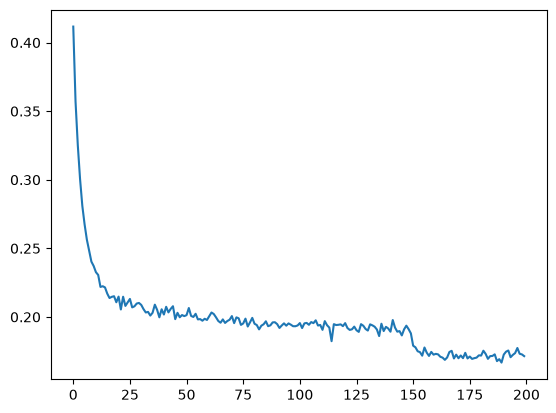

In [ ]:
# 3 karakterin örnek isimleri:

'''
baremorkuntuz.
ilkevser.
necatihnilke.
harukserunrecrinferhan.
lale.
buransevinfer.
vuvgealpfundan.
zeynelyasirıla.
zümrütuğçe.
gökalpçıafundoğaberen.
reşat.
selifturannihantuğ.
revutilgın.
beyda.
polat.
ipek.
yasemiray.
yaz.
büşra.
mutkartülaylantulaş.
'''

## Görev 2

In [ ]:
# Bağlamı 3 harften 8'e çıkar. Başka hiçbir şeyi değiştirmeden aynı düz modeli koş, dev loss'u kaydet. Bu senin karşılaştırma tabanın. Parametre sayısı ne kadar arttı, loss ne kadar düştü, yaz. (17:11 - 21:36)

In [ ]:
# 8 karakter ile loss çıktısı:
'''
0/ 200000: 3.4144
  10000/ 200000: 1.4413
  20000/ 200000: 1.7853
  30000/ 200000: 1.4081
  40000/ 200000: 1.6868
  50000/ 200000: 1.6626
  60000/ 200000: 1.4601
  70000/ 200000: 1.5990
  80000/ 200000: 1.7615
  90000/ 200000: 1.5849
 100000/ 200000: 0.9423
 110000/ 200000: 1.4800
 120000/ 200000: 1.7072
 130000/ 200000: 1.5111
 140000/ 200000: 1.4984
 150000/ 200000: 1.4001
 160000/ 200000: 1.2572
 170000/ 200000: 1.2812
 180000/ 200000: 1.0631
 190000/ 200000: 1.3064
'''
# parametre sayısı: 22730

# train 1.2263916730880737
# val 1.2500290870666504

## 8 karakter ile bir sonraki karakteri tahmin ettiğimizde loss eğrisi

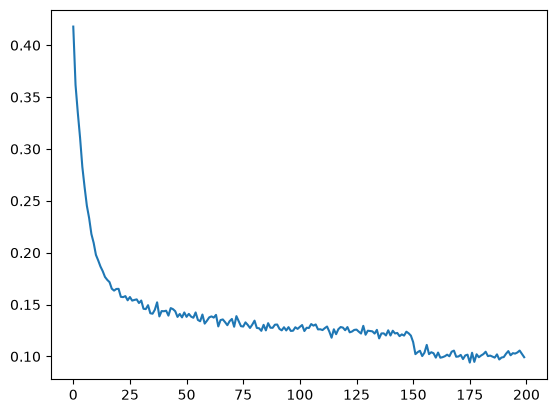

In [ ]:
# 8 karakter ile örnek isim:

'''
çınaryiğit.
onurjülide.
asumanbilek.
cemalra.
selimzameva.
ufukyağmur.
görkemdoğakan.
irfansibel.
metehangen.
sehernada.
oyaharuğ.
ibrahimsevgi.
ömerpelin.
uğurcaner.
yıldızderin.
ecedilay.
reşatoprak.
ihsancemay.
oğulcannazlı.
yazmetis.
'''

### karşılatırma:
- contex = 3 + 200 hidden layers -> parametre sayısı: 12730 ve train loss: 1.4506 ve val loss: 1.4633
- contex = 8 + 200 hidden layers -> parametre sayısı: 22730 ve train loss: 1.2264 ve val loss: 1.2500

## Görev 3

In [ ]:
# WaveNet'i kur. 8 harfi tek seferde düzleştirmek yerine ikişer ikişer birleştir, üç katmanda tek vektöre in. Her katmanın çıktısının şeklini yazdır ve o şeklin neden öyle olduğunu kendi cümlelerinle yaz. (21:36 - 37:41)

In [ ]:
# neden WaveNet mimarisini kullanıyoruz tek seferde birleştirmek yerine katmanlara bölüyoruz ?
# - 8 karakteri tek seferde düzleştirdiğimizde 8 * vektör boyutu olduğu için 80 boyutlu bir girdiden 200 hidden layer olduğu için 200 boyutlu bir çıktıya gitmek zorunda.
# - Bu katman aynı anda tüm olası kombinasyonları örneğin karakter 1 ile karakter 7 nin ilişkisini ya da 1 ile karakter 8 in ilişkisini aynı anda öğrenmek zorunda.
# - şimdi ise ikili gruplar halinde yaparak katman katman önce iki karakter ne öğrenir sonra ise 4 ve 8 karakter ne öğrenir diyerek her katman bir öncekinin üzerine bilgi inşa eder.



# (1, 2) (3, 4) (5, 6) (7, 8) 
# (1,2,3,4) , (5,6,7,8)
# (1, 2, 3, 4, 5, 6, 7, 8)

In [125]:
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident 

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

171530


In [113]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)

In [114]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 30)


In [ ]:
# (B=4, n_embd=10, n_hidden=200, vocab_size=30) örnek olarak batch sizeı 4 verdik 10 embedding vektor boyutu hidden leayr 200 ve 30 tan karakterimiz var. 
# Embedding : (4, 8, 10) -> 4 tane örnek seçmiştik videoda 8 tane karakter üzerinde 10 tane vektörü temsil ediyor 
# FlattenConsecutive : (4, 4, 20) -> formülsel olarak baktığımızda x = x.view(B, T//self.n, C*self.n) embedding katmanı (4, 8, 10) FlattenConsecutive(2) seçtiğimiz için yani 
# ikişerli olarak katmnalaştırdığımızda n yerine 2 koyduğumuzda (4, 8 / 2, 10*2)  ve  (4, 4, 20) olur 
# peki formülsel olarak hep böyle gidecektir ancak biz nasıl olduğunu anlatalım.
# ilk olarak embedding te (4, 8, 10) du yani (1)(2)(3)(4)(5)(6)(7)(8)  8 karakter 10 tane vektör boyutlu sonra FlattenConsecutive(2) ile yani 2 şerli olarak birleştir demek 
# FlattenConsecutive: (4, 4, 20) oldu yani  (1,2) (3,4) (5,6) (7,8)   4 tane grup var ikişerli ikişerli birleşmiş ve vektör boyutu yan yana koyulduğu için iki katına çıktı.
# geçelim Linear : (4, 4, 200) bu katmana neden böyle çıktı ? 
# Linear(n_embd * 2, n_hidden, bias=False) önceki katmandan (4, 4, 20) girdisini aldı linear ancak linearın formülüne baktığımızda Linear(20, 200) olur bu da (4, 4, 200) çıkmasını sağlar.
# BatchNorm1d : (4, 4, 200)  bir önceki katmandan Linear : (4, 4, 200) girdisini aldık batchnorm normalizasyon yaptığı shapi değiştirmediği için formüle göre --> FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
# BatchNorm1d(n_hidden) olduğu için bu katmanda aynı shapi verir (4, 4, 200) 
# Tanh : (4, 4, 200) bir önceki katmandan (4, 4, 200) girdisini aldık tanh nonlinarite kattığını biliyoruz o yüzden yine shapi değişmyecektir (4, 4, 200) olarak kalır.
# FlattenConsecutive : (4, 2, 400) biz önceki katmandan (4, 4, 200) girdisini almıştık şimdi   (1,2) (3,4) (5,6) (7,8) bu kısımdaydık sadece normalize ettik ve tanh ile nonlinearite kattık.
# şimdi ise 4 örnekten 2 gruplu ve 400 boyutlu vektör lü katmanımız oldu       (1,2,3,4) , (5,6,7,8)  son çıktı FlattenConsecutive: (4, 2, 400)
# Linear : (4, 2, 200)  bir önceki katmandan (4, 2, 400) aldık formüle baktığımzda ne girdi alırsak alalım  Linear(n_embd * 2, n_hidden, bias=False) hidden layer 200 olduğu için son çıktımız tekrar (4, 2, 200) oldu.
# BatchNorm1d : (4, 2, 200)  bir önceki katmandan (4, 2, 200) aldık batchnorm normalize yaptığı shapi değiştirmediği için bir de formül BatchNorm1d(n_hidden) olduğu için çıktı aynı kalır.
# Tanh : (4, 2, 200) aynnı şekilde nonlinearite kattığı için aynı kalır son çıktı (4, 2, 200) olur.
# FlattenConsecutive : (4, 400) bir önceki katmandan (4, 2, 200) aldık en sonki gurubuzum (1,2,3,4) , (5,6,7,8) artık tek vektör ile temsil edeceğiz. (1, 2, 3, 4, 5, 6, 7, 8) 200 * 2 den 400 boyutlu vektöre elde etmiş olduk.
# Linear : (4, 200) bir önceki katmandan (4, 400) girdisini aldık linear tekrar 200 hidden layer olduğu için (4, 200) çıktısını verdi 
# BatchNorm1d : (4, 200) bir önceki katmandan (4, 200) girdisini aldık batch norm normalize kattı çıktı yine aynı (4, 200) oldu.
# Tanh : (4, 200) nonlinarite kattı ve aynı kaldı çıktı -> (4, 200)
# Linear : (4, 30) artık son katmanda olduğu için 30 tane harf olduğu için çıktı 30 olmalı ve 4 örnek üzerinden gittiğimiz için (4, 30) oldu.

## Görev 4

In [115]:
# Şekilleri yazdırırken BatchNorm1d'nin üç boyutlu girdide yanlış çalıştığını göreceksin. Hatanın ne olduğunu ve ortalamanın hangi eksenlerde alınması gerektiğini göster, düzelt, modeli yeniden eğit. Düzeltmeden önceki ve sonraki dev loss'u yan yana koy. (37:41 - 46:07)

## bug ile WaveNet training

In [156]:
n_embd = 10
n_hidden = 200

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident 

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

171530


In [157]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.4041
  10000/ 200000: 1.2937
  20000/ 200000: 1.0518
  30000/ 200000: 1.5676
  40000/ 200000: 1.3285
  50000/ 200000: 1.5591
  60000/ 200000: 1.5576
  70000/ 200000: 1.0011
  80000/ 200000: 1.2265
  90000/ 200000: 1.4802
 100000/ 200000: 1.2619
 110000/ 200000: 1.3515
 120000/ 200000: 0.9362
 130000/ 200000: 1.3020
 140000/ 200000: 1.4514
 150000/ 200000: 1.5038
 160000/ 200000: 0.9965
 170000/ 200000: 0.8994
 180000/ 200000: 1.3502
 190000/ 200000: 1.2944


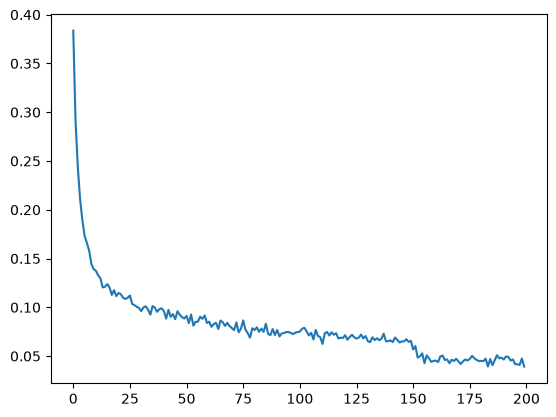

In [158]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [159]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 200)
BatchNorm1d : (32, 4, 200)
Tanh : (32, 4, 200)
FlattenConsecutive : (32, 2, 400)
Linear : (32, 2, 200)
BatchNorm1d : (32, 2, 200)
Tanh : (32, 2, 200)
FlattenConsecutive : (32, 400)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 30)


In [160]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.1160621643066406
val 1.1432991027832031


### Bug çözümü

In [131]:
e = torch.randn(32, 4, 200)
emean = e.mean(0, keepdim=True) 
print(emean.shape)
evar = e.var(0, keepdim=True)
print(evar.shape)
ehat = (e - emean) / torch.sqrt(evar + 1e-5)
print(ehat.shape)

torch.Size([1, 4, 200])
torch.Size([1, 4, 200])
torch.Size([32, 4, 200])


In [132]:
e = torch.randn(32, 4, 200)
emean = e.mean((0, 1), keepdim=True) 
print(emean.shape)
evar = e.var((0, 1), keepdim=True)
print(evar.shape)
ehat = (e - emean) / torch.sqrt(evar + 1e-5)
print(ehat.shape)

torch.Size([1, 1, 200])
torch.Size([1, 1, 200])
torch.Size([32, 4, 200])


In [ ]:
# Batchnormdaki hatayı buluyoruz 
# yukarıdaki örneğe göre (32, 4, 200) input aldığını düşünelim batchnorum
# batchnormun görevi: videoda kanal olarak isimlendiriyor ve amaç kanalın tipik ortalama değeri ve varyansı ne ? bunu bulmak ve elimizde 200 ortalama ve 200 varyans kalmalı
# yukarıda (32, 4, 200) girdisine göre mean ve varyans (1, 4, 200) değerini veriyor ancak bizim her seferinde sadece 1 tane 200 mean ve varyansa ihtiyacımız var
# o yüzden emeanın shape i (1, 1, 200) çıkmalı yani 1 tane T kodda tanımladığımız zaman ekseni kısmı B, T, C = x.shape  x = x.view(B, T//self.n, C*self.n) buradaki T 1 e indi 
# aşağıdaki kodda bunu düzeltmiş olduk 2D ve 3D li tensorler için sorun çıkamış oluyor
#
# if self.training:
#    if x.ndim == 2:
#       dim = 0
#     elif x.ndim == 3:
#        dim = (0,1)
#    xmean = x.mean(dim, keepdim=True) # batch mean
#    xvar = x.var(dim, keepdim=True) # batch variance


# ehat ne demek?  Bu aslında istatistikte z skorunun formülü
# ehat = (e - emean) / torch.sqrt(evar + 1e-5)

### Düzeltmeden Önceki ve Sonraki loss:
- Düzeltmeden önceki: train 1.1226778030395508 , val 1.1500463485717773
- Düzelttikten sonra: train 1.1160621643066406 , val 1.1432991027832031

## Görev 5

In [ ]:
#  Modeli büyüt: embedding boyutunu ve katman genişliğini artır. Tek tablo çıkar, üç satır olsun: bağlam 3 MLP, bağlam 8 düz MLP, bağlam 8 WaveNet. Sütunlar parametre sayısı ve dev loss. (46:07 - 46:58)

In [182]:
# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident 

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

77038


In [183]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.4042
  10000/ 200000: 0.9971
  20000/ 200000: 1.5965
  30000/ 200000: 1.8011
  40000/ 200000: 1.4443
  50000/ 200000: 1.3629
  60000/ 200000: 0.8068
  70000/ 200000: 1.5037
  80000/ 200000: 1.3957
  90000/ 200000: 1.2413
 100000/ 200000: 1.0519
 110000/ 200000: 1.1759
 120000/ 200000: 1.3607
 130000/ 200000: 1.3168
 140000/ 200000: 1.1844
 150000/ 200000: 1.7290
 160000/ 200000: 1.2509
 170000/ 200000: 1.2598
 180000/ 200000: 1.3783
 190000/ 200000: 1.4211


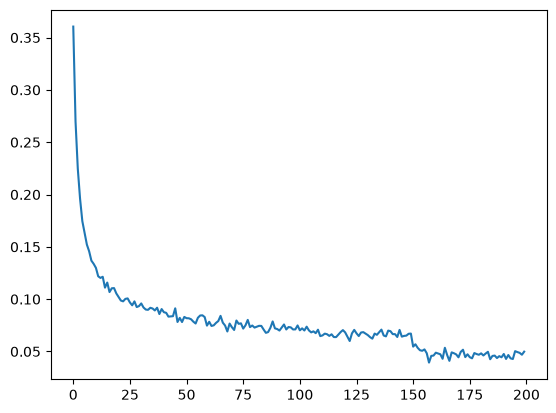

In [184]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [185]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.1181923151016235
val 1.142990231513977


In [186]:
for layer in model.layers:
  layer.training = False

In [188]:
import pandas as pd

data = {
    "Model": ["bağlam 3 MLP", "bağlam 8 düz MLP", "bağlam 8 WaveNet"],
    "Parametre Sayısı": [12730, 22730, 77038],   
    "Train Loss": [1.4505501985549927, 1.2263916730880737, 1.1175992488861084],       
    "Val Loss": [1.4633435010910034, 1.2500290870666504, 1.1432867050170898],         
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

           Model  Parametre Sayısı  Train Loss  Val Loss
    bağlam 3 MLP             12730    1.450550  1.463344
bağlam 8 düz MLP             22730    1.226392  1.250029
bağlam 8 WaveNet             77038    1.117599  1.143287


## Görev 6

In [ ]:
# Türkçe isim listenle aynı WaveNet'i eğit. Ürettiği isimlerden örnek ver, dev loss'u hafta 4'ün Türkçe MLP'siyle karşılaştır. Türkçe'de bağlamı 8'e çıkarmak ne kazandırdı, yaz.

In [189]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

aslanmelis.
edizıla.
hüseyinlale.
tanerce.
jülidetaylan.
handanbertan.
tijençiçek.
vedatfurkan.
fikretcaner.
ebrutuğçe.
ulviyedal.
rüştozeynel.
hüseyingündüz.
leventpelin.
bahartuğ.
ilgıngöktürk.
atakantuz.
reniloktay.
gökhansedat.
güneşasel.


In [190]:
# Bu isimlerin böyle olmasının sebebi sırf veri sayısını arttırmak için şu anda 103 bin satır. Yapay zekanın ürettiği 1000 
# isimli txt az geldiği için 2'li isimlerin olmasına izin verdim yani temizlemedim.

### Loss değişimi:
- Hafta 4 MLP loss: 1.4668
- WaveNet 8 contextli loss: 1.1432878

In [ ]:
# 4. hafta Türkçe MLP'den ürettiğim örnek isimler
'''
fikretışık.
azrasim.
ser.
irfan.
ayşe.
orhanhümeyrazçağlavaşzerr.
nilil.
yusuferihatuhan.
selingün.
doğa.
vdoğa.
kaya.
han.
esmailgınilüferberk.
nazerrihati.
poyra.
jalezar.
ayzörkem.
pamuk.
ike.

'''

## Çıkarım
- Üretilen isimler daha isim gibi görünmeye başladı ikili gruplar benim suçum bilerek öyle bir dataset kullanmak istedim örnek syaısı çok olsun diye ancak isimlerin performansı arttı.
- Loss görünür bir şekilde düştü.
- 4.haftada MLP de context 3 tü bu hafta 8 yaptık bu aslında parametre sayısını arttırdı ve modelin daha iyi öğrenmesini / sonuç vermesini sağladı.

## Görev 7

In [ ]:
# Ek, erken bitirenler için, üçünden biri. (a) Aynı hiyerarşik yapıyı torch.nn.Conv1d ile dilated causal convolution olarak kur, iki modelin aynı sonucu verdiğini göster (47:44 - 51:34). (b) Konfigürasyonları tek tek elle denemek yerine listeden okuyup sonuçları tabloya yazan küçük bir deney düzeneği yaz (46:58 - 47:44). (c) Karpathy videonun sonunda kendi loss'unu geçmeye çağırıyor, kabul et: hiperparametrelerle oyna, onun sayısını geç, ne denediğini not et (55:26 - 56:21).

In [199]:
for x,y in zip(Xtr[8:16], Ytr[8:16]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> o
......do --> ğ
.....doğ --> a
....doğa --> c
...doğac --> e
..doğace --> m
.doğacem --> .


In [192]:
# forward a single example:
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 30])

In [194]:
# forward all of them
logits = torch.zeros(8, 30)
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
logits.shape

torch.Size([8, 30])

In [ ]:
# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space